# =====================
# Paso 3: RANDOM FOREST
# =====================

El **Random Forest (Bosque Aleatorio)** es uno de los algoritmos más potentes para datos tabulares porque maneja excelentemente las relaciones no lineales (por ejemplo, cruzar el nivel de CO2 con la Hora del día).

1. **Evaluación (`Stratified K-Fold` + `Hold-out`):** Como tienes pocos datos (~400), usar solo 80/20 es peligroso. Haremos un *Hold-out* (80% Train, 20% Test) para la prueba final ciega, pero *dentro* del 80% de entrenamiento usaremos **K-Fold Cross Validation (K=5)** para que el modelo entrene de forma robusta rotando los datos.
2. **Hiperparámetros (Las "palancas"):** Para Random Forest no usamos `C` (eso es de SVM/Logística). Optimizaremos `n_estimators` (cuántos árboles plantamos) y `max_depth` (hasta qué profundidad los dejamos crecer para que no memoricen/overfitteen).
3. **Métricas:** Nos centraremos en el **F1-Score** (pondera precisión y recall, vital porque tenemos muchos más buses "Vacíos" que "Llenos") y pintaremos la matriz de confusión.



---


### 1. Importar librerías

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import joblib
import os
from sklearn.pipeline import Pipeline



---


### 2. Montar Google Drive y Cargar



In [ ]:
# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta donde guardaste los archivos en tu Drive
ruta = "/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/LineaC1_Limpio.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




---
### 3. Entrenamiento: Random Forest


--- MODELO AVANZADO: RANDOM FOREST ---

-> Set de Entrenamiento: 322 instancias
-> Set de Evaluación (Test): 81 instancias

Iniciando GridSearchCV con Pipeline (36 candidatos x 5 folds)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Mejores Hiperparámetros Encontrados: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

   Vacío (0)       0.98      1.00      0.99        46
   Medio (1)       1.00      0.96      0.98        25
   Lleno (2)       1.00      1.00      1.00        10

    accuracy                           0.99        81
   macro avg       0.99      0.99      0.99        81
weighted avg       0.99      0.99      0.99        81


💾 Pipeline Random Forest guardado con éxito en: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/pipeline_random_forest.joblib


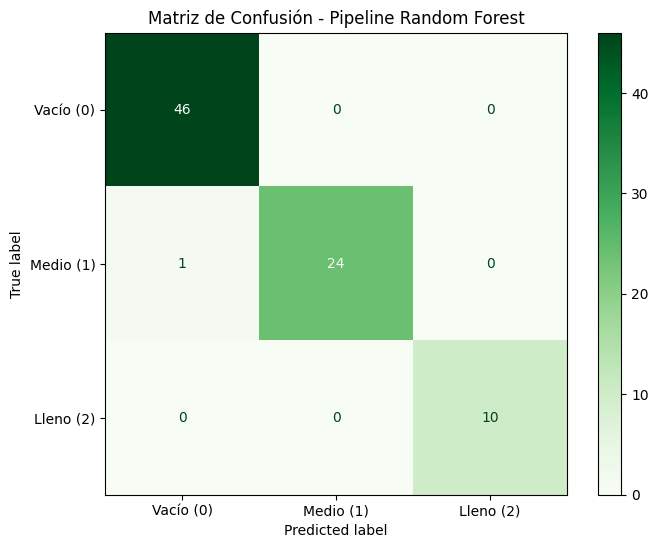

In [ ]:
print("======================================================")
print("--- MODELO AVANZADO: RANDOM FOREST ---")
print("======================================================\n")

# 1. CARGA Y LIMPIEZA DE DATOS
df = pd.read_csv(ruta).dropna(subset=['TARGET_Aforo'])

X = df[['Temperatura', 'Humedad', 'eCo2', 'Redes', 'Señal Detectada', 'Hora']]
y = df['TARGET_Aforo'].astype(int)

# 2. PARTICIÓN 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"-> Set de Entrenamiento: {X_train.shape[0]} instancias")
print(f"-> Set de Evaluación (Test): {X_test.shape[0]} instancias\n")

# 3. CREACIÓN DEL PIPELINE
# Solo incluimos el modelo, ya que el RF no requiere StandardScaler
pipeline_rf = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

# 4. HIPERPARÁMETROS (100% Fieles al Notebook Original)
# Añadimos 'rf__' por sintaxis del Pipeline, pero los valores son los tuyos.
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 5, 10, 15],
    'rf__min_samples_split': [2, 5, 10]
}

# 5. GRID SEARCH Y CROSS VALIDATION
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Iniciando GridSearchCV con Pipeline (36 candidatos x 5 folds)...")
grid_search_rf.fit(X_train, y_train)

# 6. EVALUACIÓN FINAL
mejor_pipeline = grid_search_rf.best_estimator_
print(f"\n✅ Mejores Hiperparámetros Encontrados: {grid_search_rf.best_params_}\n")

y_pred_rf = mejor_pipeline.predict(X_test)
target_names = ['Vacío (0)', 'Medio (1)', 'Lleno (2)']

print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

# 7. GUARDAR EL PIPELINE PARA XAI
ruta_resultados = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/'
os.makedirs(ruta_resultados, exist_ok=True)
ruta_archivo_rf = os.path.join(ruta_resultados, 'pipeline_random_forest.joblib')

joblib.dump(mejor_pipeline, ruta_archivo_rf)
print(f"\n💾 Pipeline Random Forest guardado con éxito en: {ruta_archivo_rf}")

# 8. MATRIZ DE CONFUSIÓN
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    mejor_pipeline, X_test, y_test,
    display_labels=target_names,
    cmap='Greens',
    ax=ax
)
plt.title("Matriz de Confusión - Pipeline Random Forest")
plt.show()



---



### 4. Entendiendo el Ajuste de Hiperparámetros

El mayor riesgo del Random Forest es el **Overfitting**. Si dejamos que el árbol crezca sin límite, memorizará los datos de entrenamiento y fallará en el de evaluación.

### ¿Qué esperar del resultado en Colab?

El Random Forest debería darno un **F1-Score global excelente**. Pero nuestra misión como evaluador es mirar la **Matriz de Confusión**:

* Compara esta matriz verde con la azul de la Regresión Logística.
* ¿Cuál de los dos modelos acierta más veces en la esquina inferior derecha (Predice LLENO cuando realmente es LLENO)?

El modelo que tenga el número más alto en esa casilla sin equivocarse en las demás, será el ganador definitivo para nuestro sistema de ruteo dinámico.


--- PESO DE CADA SENSOR EN LA DECISIÓN (XAI GLOBAL) ---


,Variable,Importancia
2,eCo2,0.751613
0,Temperatura,0.088877
1,Humedad,0.083519
4,Señal Detectada,0.032870
5,Hora,0.021840
3,Redes,0.021282


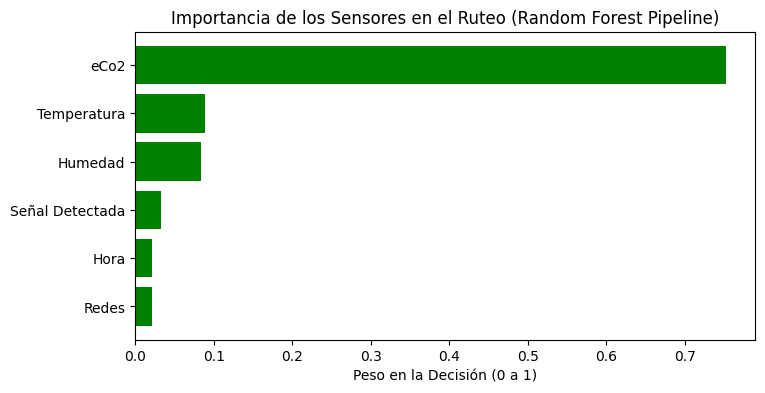

In [ ]:
# --- IMPORTANCIA DE VARIABLES (EXPLICABILIDAD DEL MODELO BASE) ---
# CORRECCIÓN: Al usar un Pipeline, debemos "extraer" el modelo Random Forest de su interior
modelo_rf_interno = mejor_pipeline.named_steps['rf']
importancias = modelo_rf_interno.feature_importances_

# Los nombres de las variables (X_train) se mantienen igual
nombres_variables = X_train.columns

# Crear un DataFrame para visualizarlo
df_importancias = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

print("\n--- PESO DE CADA SENSOR EN LA DECISIÓN (XAI GLOBAL) ---")
display(df_importancias)

# Graficar
plt.figure(figsize=(8, 4))
plt.barh(df_importancias['Variable'], df_importancias['Importancia'], color='green')
plt.gca().invert_yaxis()
plt.title("Importancia de los Sensores en el Ruteo (Random Forest Pipeline)")
plt.xlabel("Peso en la Decisión (0 a 1)")
plt.show()